In [1]:
#### mv utils ####
import modules.data as d
import modules.model as m
import modules.train as t
import modules.utils as u

#### packages ####
import torch
import torch.nn as nn
from torch_geometric.data import InMemoryDataset, Data

import pandas as pd
import numpy as np
import os
from pathlib import Path

from sklearn.preprocessing import RobustScaler, StandardScaler
from modules.model import _get_edge_index
from modules.utils import vprint

#### typing ####
from torch import Tensor
from pandas import DataFrame
from typing import Literal

In [2]:
#### init data ####

# dataset dir
datasets = Path('/home/mv18gs/Documents/GitHub/pathway_model/datasets/')

# get device
device, generator = u.Devices().auto_set_device(['cuda:1', 'cuda:0'])

*** Device() ***
device = cuda:2



---

In [3]:
def dict_summary(_dict:dict, width:int=24):
    # init str
    out = ''

    for key, value in _dict.items():
        # get variable shape
        if type(value) == pd.DataFrame:
            shape = value.shape
        elif type(value) in [torch.Tensor, np.ndarray]:
            shape = tuple([i for i in value.shape])
        elif type(value) in [list, dict]:
            shape = len(value)
        elif type(value) in [int, str, bool]:
            shape = value
        elif type(value) == float:
            shape = f'{value:.4f}'
        else:
            shape = None

        # append shape if applicable
        if shape != None:
            try:
                out += f'# {key:<{width}} {str(shape):<{width}} {type(value).__name__} ({value.device.__str__()})\n'
            except:
                out +=  f'# {key:<{width}} {str(shape):<{width}} {type(value).__name__}\n'
        else:
            out += f'# {key:<{width}} {type(value).__name__}\n'

    return out

In [4]:
class Preprocessor():
    def __init__(
        self, 
        # paths
        tcga_project:str, 
        tcga_dir:str, 
        relation_filepath:str, 

        # sample preprocessing
        metadata_subtype_col:str='', 
        log0_method:Literal['log1p','offset']='log1p',
        apply_DESeq_norm:bool=True, 
        log_transform:bool=False,
        scale_method:Literal['robust', 'standard', None]=None,

        # filter, resample, etc.
        y_col:str='type',
        y_format:Literal['index','onehot']='index',
        drop:list[str]=None,
        max_subset:int=None,
        edge_method:Literal['in','out']='in',
        verbose:bool=True,

        # fc
        apply_fold_change:bool=True,
        metadata_ctrl:str='Normal',
    ):
        '''
        Class to format and preprocess TCGA data, TCGA metadata, and KEGG relation data.
        '''
        
        vprint('# #### Preprocessor() ####', verbose=verbose)
        
        # assign params to inst vars
        self.log0_method = log0_method

        # read files into df
        gene_counts = self._read_gene_counts(tcga_project, tcga_dir)
        metadata = self._read_metadata(tcga_project, tcga_dir, metadata_subtype_col)
        relation = pd.read_csv(relation_filepath)

        # data preprocessing
        if apply_DESeq_norm == True:
            gene_counts = self._DESeq_norm(gene_counts)
            self.deseq = gene_counts

        if apply_fold_change == True:
            gene_counts = self._fold_change(gene_counts, metadata, metadata_ctrl)

        if log_transform == True:
            gene_counts = np.log(self._handle_log0(gene_counts))

        if scale_method != None:
            gene_counts = self._scale_gene_counts(gene_counts, scale_method)

        # preprocess gene_counts and relation into graph data
        gene_counts, relation, node_id_map = self._graph_preprocessing(gene_counts, relation)

        # get masks, flatten relation
        masks = self._get_masks(relation)
        relation = relation.drop(columns='pathway_name').groupby(['idx1','idx2'], as_index=False).any()

        # filter counts by class (drop classes, downsample) if applicable
        gene_counts, metadata = self._filter_counts(gene_counts, metadata, y_col, drop, max_subset)

        # get xy
        x, y, y_labels = self._get_xy(gene_counts, metadata, y_col, y_format)

        # get class_weights
        self.class_weights = y.shape[0]/y.sum(dim=0)

        # get edge information
        self.edge_index, self.edge_attr = self._get_edges(relation, edge_method)

        # assign instance variables
        self.gene_counts = gene_counts
        self.metadata = metadata
        self.relation = relation
        self.node_id_map = node_id_map
        self.masks = masks
        self.x = x
        self.y = y
        self.y_labels = y_labels

        # get dims
        self._get_dims(y_format)
        vprint(self, verbose=verbose)

    def _read_gene_counts(self, tcga_project:str, tcga_dir:str):
        # read df
        df = pd.read_csv(Path(tcga_dir) / f'{tcga_project}_gene_counts.csv')

        # rename 'Unnamed: 0' col if applicable
        if 'Unnamed: 0' in df.columns:
            df = df.rename(columns={'Unnamed: 0':'ensg'})

        # remove ensg version
        df['ensg'] = df['ensg'].str.split('.').str[0]

        # set index, column name
        df = df.set_index('ensg')
        df.columns.name = 'barcode'

        return df

    def _read_metadata(self, tcga_project:str, tcga_dir:str, metadata_subtype_col:str):
        # read df
        df_complete = pd.read_csv(Path(tcga_dir) / f'{tcga_project}_metadata.csv')

        # drop 'Unnamed: 0' col if applicable
        if 'Unnamed: 0' in df_complete.columns:
                df_complete = df_complete.drop(columns='Unnamed: 0')

        # compile df
        df = pd.DataFrame(
            {
                'barcode': df_complete['barcode'],
                'type': df_complete.apply(lambda row: row['name'] if row['tissue_type'] == 'Tumor' else row['tissue_type'], axis=1),
            }
        )

        # append subtype if applicable
        if metadata_subtype_col != '':
            df['subtype'] = df_complete[metadata_subtype_col].fillna(df_complete['sample_type'])

        return df
    
    def _fold_change(self, gene_counts:pd.DataFrame, metadata:pd.DataFrame, metadata_ctrl:str):
        # get control barcodes
        ctrl_barcodes = metadata[metadata['type'] == metadata_ctrl]['barcode']

        # get mean
        ctrl_avg = gene_counts[ctrl_barcodes].mean(axis=1).values.reshape(-1, 1) # reshape to allow division

        # get fc
        return gene_counts / ctrl_avg
    
    def _handle_log0(self, x):
        # offset (replace 0 with small number)
        if self.log0_method == 'offset':
            if type(x) == pd.DataFrame:
                x = x.replace(0, 1e-6)
            else:
                x = x + 1e-6 # if x is not a df, add 1e-6

        # log1p method (add 1 before log)
        elif self.log0_method == 'log1p':
            x = x + 1

        # error msg
        else:
            print("Invalid log0 method; log0 method not applied. Use 'offset' or 'log1p'.")

        return x

    def _DESeq_norm(self, gene_counts:pd.DataFrame):
        # handle log zero
        gene_counts = self._handle_log0(gene_counts)

        # take the (natural) log of all the values
        log_counts = np.log(gene_counts)

        # average each row (e.g., geometric average)
        geom_avg = log_counts.mean(axis=1)

        # filter out +-inf
        geom_avg_filt = geom_avg[(abs(geom_avg) != np.inf)]

        # subtract the average log value from the log(counts)
        log_ratio = log_counts.sub(geom_avg_filt, axis=0)

        # caclulate the median of the ratios for each sample
        log_ratio_median = log_ratio.median()

        # calculate scaling factors (e^log_ratio_median)
        scaling_factor = log_ratio_median.apply(lambda x: np.exp(x))

        # divide the original read counts by the scaling factors; return output
        return gene_counts.div(scaling_factor, axis=1)
    
    def _scale_gene_counts(self, gene_counts:pd.DataFrame, scale_method:Literal['robust', 'standard', None]=None,
):
        # return if none
        if scale_method == None:
            return gene_counts

        # select scaler        
        if scale_method == 'robust':
            scaler = RobustScaler()
        elif scale_method == 'standard':
            scaler = StandardScaler()

        # scale data
        scaled_values = scaler.fit_transform(gene_counts.T).T

        # convert to df
        gene_counts = pd.DataFrame(
            scaled_values,
            index=gene_counts.index,
            columns=gene_counts.columns
        )

        return gene_counts
    
    def _graph_preprocessing(self, gene_counts:pd.DataFrame, relation:pd.DataFrame):
        # filter gene_counts by relation ensembl
        unique_ensg = pd.concat([relation[cols] for cols in ['ensembl1', 'ensembl2']]).unique().tolist()
        gene_counts = gene_counts.loc[unique_ensg,:]

        # get id maps
        node_id_map = {node: int(i) for i, node in enumerate(gene_counts.index)}

        # map relation ensembl id to nodes
        relation['idx1'] = relation['ensembl1'].map(node_id_map)
        relation['idx2'] = relation['ensembl2'].map(node_id_map)

        # replace ensembl with idx
        cols = relation.columns.to_list()
        cols = [col for col in cols if col not in ['pathway_name', 'ensembl1', 'ensembl2','idx1','idx2']]
        cols = ['pathway_name', 'idx1', 'idx2'] + cols
        relation = relation.loc[:,cols]

        return gene_counts, relation, node_id_map

    def _get_masks(self, relation:pd.DataFrame):
        # initialize empty dict
        mask_nodes = {}

        # iterate through df grouped by mask_id
        for mask_id, group in relation.groupby('pathway_name'):
            nodes = pd.concat([group['idx1'], group['idx2']]).unique() # get unique nodes in idx1 & idx2
            mask_nodes[mask_id] = nodes.tolist() # append to dict

        # list masks
        masks = [j for _,j in mask_nodes.items()]

        return masks
    
    def _filter_counts(self, gene_counts:pd.DataFrame, metadata:pd.DataFrame, y_col:str, drop:dict, max_subset:int):
            # drop cols by class
            if (drop != None) & (type(drop) == dict):
                for key, value in drop.items():
                    metadata = metadata[~metadata[key].isin(value)]

            # downsample
            if (max_subset != None) & (type(max_subset) == int):

                # helper fxn
                def downsample(group):
                    if len(group) > max_subset:
                        return group.sample(n=max_subset)
                    return group
                
                # apply downsampling
                metadata_grouped = metadata.groupby(y_col)
                metadata_grouped = metadata_grouped.apply(downsample, include_groups=False).reset_index(drop=True)

                # reappend y_col, reorder
                metadata = pd.merge(metadata_grouped, metadata[['barcode', y_col]], on='barcode', how='left')
                metadata = metadata[['barcode','type','subtype']]

            # apply filter
            gene_counts = gene_counts[metadata['barcode']]

            return gene_counts, metadata

    def _get_xy(self, gene_counts:pd.DataFrame, metadata:pd.DataFrame, y_col:str, y_format:Literal['index','onehot']):
        # format x
        x = gene_counts.T
        x = x.values.astype(np.float32)
        x = np.expand_dims(x, axis=-1) # reshape to (num_samples, num_nodes, 1)
        x = torch.tensor(x)

        # format y
        y_labels = metadata[y_col]
        y = pd.get_dummies(y_labels).values.astype(np.float32)
        y_labels = y_labels.unique().tolist()        
        y = torch.tensor(y)

        # convert y to index, if applicable
        y = y.argmax(dim=1) if y_format == 'index' else y
        
        return x, y, y_labels

    def _get_edges(self, relation:DataFrame, edge_method:Literal['in','out'], source:str='idx1', target:str='idx2'):
        # get edge information >> (num_edges, 2)
        if edge_method == 'in':
            edge_index = relation[[target, source]]
        elif edge_method == 'out':
            edge_index = relation[[source, target]]
        
        # transpose, convert to tensor >> (2, num_edges) 
        edge_index = torch.tensor(edge_index.values.T, dtype=torch.int64)

        # get edge attr
        attr_cols = relation.columns.drop([source, target])
        if len(attr_cols) > 0:
            edge_attr = torch.tensor(relation[attr_cols].values, dtype=torch.int64)
        else:
            edge_attr = None

        return edge_index, edge_attr

    def _get_dims(self, y_format:Literal['index','onehot']):
        # x
        self.num_samples, self.num_nodes, self.num_node_features = self.x.shape

        # y
        if y_format == 'onehot':
            _, self.num_classes = self.y.shape
        else:
            self.num_classes = self.y.unique().size(0)

        # masks
        self.num_masks = len(self.masks)

        # edges
        self.num_edges, self.num_edge_features = self.edge_attr.shape
    
    def __str__(self):
        return dict_summary(self.__dict__)



In [5]:
brca = Preprocessor(
    tcga_project='TCGA-BRCA',
    tcga_dir=datasets/'tcga',
    relation_filepath=datasets/'other'/'relation_ohe.csv',
    
    metadata_subtype_col = 'paper_BRCA_Subtype_PAM50',
    y_col = 'subtype',
    drop = {'subtype':['Normal', 'Primary Tumor']},
    max_subset = 120,
    apply_DESeq_norm=True, 
    log_transform=True,
    scale_method=None,
    apply_fold_change=False
)

# #### Preprocessor() ####
# log0_method              log1p                    str
# deseq                    (60660, 1231)            DataFrame
# class_weights            ()                       Tensor (cuda:2)
# edge_index               (2, 32798)               Tensor (cuda:2)
# edge_attr                (32798, 16)              Tensor (cuda:2)
# gene_counts              (4383, 562)              DataFrame
# metadata                 (562, 3)                 DataFrame
# relation                 (32798, 18)              DataFrame
# node_id_map              4383                     dict
# masks                    305                      list
# x                        (562, 4383, 1)           Tensor (cuda:2)
# y                        (562,)                   Tensor (cuda:2)
# y_labels                 6                        list
# num_samples              562                      int
# num_nodes                4383                     int
# num_node_features        1                  

In [6]:
brca.x.shape

torch.Size([562, 4383, 1])

In [7]:
brca.y.shape

torch.Size([562])

In [8]:
brca.edge_index.shape

torch.Size([2, 32798])

In [9]:
brca.edge_attr.shape

torch.Size([32798, 16])

---

In [10]:
brca.gene_counts.T.max().max()

14.658252479961808

In [11]:
import seaborn as sns

In [12]:
test_df = brca.gene_counts.T

def get_metrics(df):
    metrics = df.describe().T
    metrics['skew'] = df.skew()
    metrics['kurtosis'] = df.kurtosis()

    return metrics

In [13]:
metrics = get_metrics(test_df)
metrics

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
ensg,,,,,,,,,,
ENSG00000204310,562.0,7.605904,0.467729,3.829202,7.402989,7.654744,7.864909,8.815425,-1.789570,10.072413
ENSG00000169692,562.0,8.087648,0.829057,4.627988,7.551701,8.040127,8.548524,10.847920,0.256443,1.199713
ENSG00000067113,562.0,7.185512,0.801327,4.277448,6.631740,7.092248,7.701382,9.381574,0.204876,0.111639
ENSG00000141934,562.0,8.329606,0.917249,3.181862,8.014173,8.466046,8.844031,10.405115,-1.918192,6.003597
ENSG00000162407,562.0,8.029265,0.817714,4.806414,7.489704,7.965418,8.495354,10.280485,0.017185,0.403271
...,...,...,...,...,...,...,...,...,...,...
ENSG00000198648,562.0,7.728457,0.758216,4.793571,7.289662,7.682795,8.235288,9.894477,-0.249940,0.680612
ENSG00000172939,562.0,8.188909,0.444394,6.621822,7.951074,8.217065,8.475100,9.804164,-0.385428,0.843881
ENSG00000138777,562.0,8.153497,0.449043,5.807282,7.898933,8.165069,8.449117,9.369547,-0.384419,1.328053


In [14]:
test_df.max().max()

14.658252479961808

In [15]:
metrics.max()

count       562.000000
mean         12.536111
std           3.203850
min          10.007948
25%          12.245989
50%          12.570400
75%          13.028909
max          14.658252
skew          8.320140
kurtosis     82.365367
dtype: float64

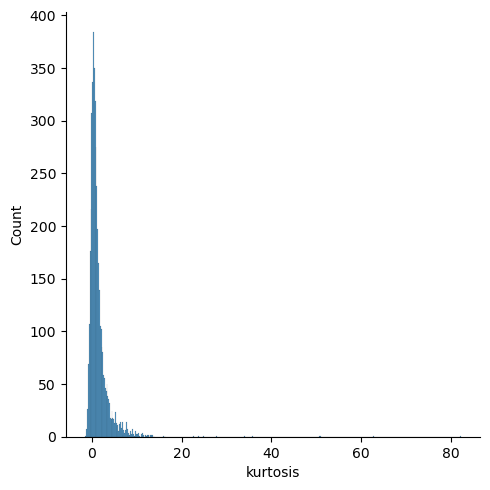

In [16]:
sns.displot(metrics['kurtosis'])

---

In [17]:
class GraphDataset(InMemoryDataset):
    def __init__(self, preprocessor:Preprocessor, verbose:bool=True, *args, **kwargs):
        # assign instance variables
        self.x = preprocessor.x
        self.y = preprocessor.y
        self.edge_index = preprocessor.edge_index
        self.edge_attr = preprocessor.edge_attr

        # super args, kwargs
        super().__init__(*args, **kwargs)

        # process data
        self.data, self.slices = self.process_data()

        # print summary
        if verbose == True:
            self.print_dims()

    def process_data(self):
        data_list = []
        num_samples = self.x.size(0)

        for i in range(num_samples):
            data = Data(
                x=self.x[i],
                edge_index=self.edge_index,
                edge_attr=self.edge_attr,
                y=self.y[i]
            )

            data_list.append(data)

        return self.collate(data_list)

    def print_dict(self):
        # get first graph in dataset
        data = self[0] 

        # format msg
        out = '# #### GraphDataset(), Dataset (Dict) ####\n'
        out += dict_summary(self.__dict__)
        out += '\n# #### GraphDataset(), Data (Dict) ####\n'
        out += dict_summary(data.__dict__)

        # print msg
        print(out)

    def print_dims(self):
        # get first graph in dataset
        data = self[0]

        # get dims
        dataset_dims = {
            'num_graphs (len)':len(self),
            'num_node_features':self.num_node_features,
            'num_edge_features':self.num_edge_features,
        }
        data_dims = {
            'num_nodes':data.num_nodes,
            'num_edges':data.num_edges,
            'num_node_features':data.num_node_features,
            'num_edge_features':data.num_edge_features,
        }
        data_summary = {
            'Average node degree': data.num_nodes / data.num_edges,
            'Has isolated nodes': data.has_isolated_nodes(),
            'Has self-loops': data.has_self_loops(),
            'Directionality': 'directed' if data.is_directed() else 'undirected'
        }

        # create msg
        out = '# #### GraphDataset(), Dataset ####\n'
        out += dict_summary(dataset_dims)
        out += '\n# #### GraphDataset(), Data ####\n'
        out += dict_summary(data_dims)
        out += '\n# #### GraphDataset(), Summary ####\n'
        out += dict_summary(data_summary)

        # print msg
        print(out)

        

In [18]:
brca_pyg = GraphDataset(brca)

# #### GraphDataset(), Dataset ####
# num_graphs (len)         562                      int
# num_node_features        1                        int
# num_edge_features        16                       int

# #### GraphDataset(), Data ####
# num_nodes                4383                     int
# num_edges                32798                    int
# num_node_features        1                        int
# num_edge_features        16                       int

# #### GraphDataset(), Summary ####
# Average node degree      0.1336                   float
# Has isolated nodes       True                     bool
# Has self-loops           True                     bool
# Directionality           directed                 str



---

In [19]:
from torch_geometric.loader import DataLoader

In [20]:
def get_dataloaders(dataset:GraphDataset, batch_size:int=64, test_size:float=0.15):
    dataset = dataset.shuffle()    
    num_samples = len(dataset)

    # train-test split
    num_train_samples = num_samples - round(num_samples * test_size)
    train_dataset = dataset[:num_train_samples]
    test_dataset = dataset[num_train_samples:]

    # create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=generator)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, generator=generator)

    # summarize dataloaders
    for step, data in enumerate(train_loader):
        print(f'Step {step + 1}:')
        print('=======')
        print(f'Number of graphs in the current batch: {data.num_graphs}')
        print(data)
        print()

    for step, data in enumerate(test_loader):
        print(f'Step {step + 1}:')
        print('=======')
        print(f'Number of graphs in the current batch: {data.num_graphs}')
        print(data)
        print()
    
    return train_loader, test_loader


In [21]:
train_loader, test_loader = get_dataloaders(brca_pyg)

Step 1:
Number of graphs in the current batch: 64
DataBatch(x=[280512, 1], edge_index=[2, 2099072], edge_attr=[2099072, 16], y=[64], batch=[280512], ptr=[65])

Step 2:
Number of graphs in the current batch: 64
DataBatch(x=[280512, 1], edge_index=[2, 2099072], edge_attr=[2099072, 16], y=[64], batch=[280512], ptr=[65])

Step 3:
Number of graphs in the current batch: 64
DataBatch(x=[280512, 1], edge_index=[2, 2099072], edge_attr=[2099072, 16], y=[64], batch=[280512], ptr=[65])

Step 4:
Number of graphs in the current batch: 64
DataBatch(x=[280512, 1], edge_index=[2, 2099072], edge_attr=[2099072, 16], y=[64], batch=[280512], ptr=[65])

Step 5:
Number of graphs in the current batch: 64
DataBatch(x=[280512, 1], edge_index=[2, 2099072], edge_attr=[2099072, 16], y=[64], batch=[280512], ptr=[65])

Step 6:
Number of graphs in the current batch: 64
DataBatch(x=[280512, 1], edge_index=[2, 2099072], edge_attr=[2099072, 16], y=[64], batch=[280512], ptr=[65])

Step 7:
Number of graphs in the current 

---

In [22]:
batch_list = [batch for batch in test_loader]
batch_list

[DataBatch(x=[280512, 1], edge_index=[2, 2099072], edge_attr=[2099072, 16], y=[64], batch=[280512], ptr=[65]),
 DataBatch(x=[87660, 1], edge_index=[2, 655960], edge_attr=[655960, 16], y=[20], batch=[87660], ptr=[21])]

In [23]:
batch_list[0].to_dict()

{'x': tensor([[6.9939],
         [7.8615],
         [6.7991],
         ...,
         [8.2568],
         [9.3550],
         [7.6305]], device='cuda:2'),
 'edge_index': tensor([[     2,      3,      4,  ..., 280509, 280510, 280511],
         [     0,      0,      0,  ..., 279485, 279485, 279485]],
        device='cuda:2'),
 'edge_attr': tensor([[0, 0, 1,  ..., 0, 0, 0],
         [0, 0, 1,  ..., 0, 0, 0],
         [0, 0, 1,  ..., 0, 0, 0],
         ...,
         [0, 0, 1,  ..., 0, 0, 0],
         [0, 0, 1,  ..., 0, 0, 0],
         [0, 0, 1,  ..., 0, 0, 0]], device='cuda:2'),
 'y': tensor([2, 1, 1, 0, 0, 2, 2, 0, 5, 5, 3, 5, 5, 1, 5, 1, 2, 3, 3, 3, 0, 2, 1, 1,
         1, 2, 0, 1, 0, 5, 2, 1, 3, 1, 3, 4, 2, 5, 2, 3, 0, 2, 3, 3, 3, 5, 0, 5,
         5, 5, 2, 0, 1, 5, 3, 5, 1, 3, 0, 1, 1, 3, 3, 5], device='cuda:2'),
 'batch': tensor([ 0,  0,  0,  ..., 63, 63, 63], device='cuda:2'),
 'ptr': tensor([     0,   4383,   8766,  13149,  17532,  21915,  26298,  30681,  35064,
          39447,  43830

---

In [24]:
from torch.nn import Linear
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.nn import global_mean_pool

In [25]:
databatch = [(step, data) for step, data in enumerate(train_loader)][0][1]
databatch

DataBatch(x=[280512, 1], edge_index=[2, 2099072], edge_attr=[2099072, 16], y=[64], batch=[280512], ptr=[65])

In [26]:
databatch.batch.unique().shape[0]

64

In [27]:
databatch.num_nodes

280512

In [28]:
# example graph classification model adapted from
# https://colab.research.google.com/drive/1I8a0DfQ3fI7Njc62__mVXUlcAleUclnb#scrollTo=CN3sRVuaQ88l

# #### define model ####

# class GCN(torch.nn.Module):
#     def __init__(self, num_node_features, num_classes, hidden_channels):
#         super(GCN, self).__init__()
#         torch.manual_seed(12345)
#         self.conv1 = GCNConv(num_node_features, hidden_channels)
#         self.conv2 = GCNConv(hidden_channels, hidden_channels)
#         self.conv3 = GCNConv(hidden_channels, hidden_channels)
#         self.lin = Linear(hidden_channels, num_classes)

#     def forward(self, x, edge_index, batch):
#         # 1. Obtain node embeddings 
#         x = self.conv1(x, edge_index)
#         x = x.relu()
#         x = self.conv2(x, edge_index)
#         x = x.relu()
#         x = self.conv3(x, edge_index)

#         # 2. Readout layer
#         x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

#         # 3. Apply a final classifier
#         # x = F.dropout(x, p=0.5, training=self.training)
#         x = self.lin(x)
        
#         return x

# model = GCN(
#     num_node_features=brca_pyg.num_node_features,
#     num_classes=brca_pyg.num_classes,
#     hidden_channels=64
# )
# print(model)

# x = model(databatch.x, databatch.edge_index, databatch.batch)
# x.shape

In [29]:
class GCN(torch.nn.Module):
    def __init__(self, num_node_features, num_classes, hidden_channels):
        super(GCN, self).__init__()
        torch.manual_seed(12345)
        self.conv = GCNConv(num_node_features, 1)
        self.lin = Linear(4383, num_classes)

    def forward(self, x, edge_index, batch):
        batch_size = batch.unique().shape[0]
        num_nodes = int(x.shape[0]/batch_size)

        # 1. Obtain node embeddings 
        x = self.conv(x, edge_index) # (batch_size * num_nodes, 1)
        # x = x.relu()

        x = x.view(batch_size, 4383)

        # 2. Readout layer
        # x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        # x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)
        
        return x

model = GCN(
    num_node_features=brca_pyg.num_node_features,
    num_classes=brca_pyg.num_classes,
    hidden_channels=64
)

In [30]:
x = model(databatch.x, databatch.edge_index, databatch.batch)
x.shape

torch.Size([64, 6])

In [31]:
x.shape[0]/64

1.0

In [32]:
# def batch_reshape(x, batch_index, batch_size):
#     num_nodes = int(x.shape[0]/batch_size)

#     # Initialize the output
#     output = torch.zeros(batch_size, num_nodes, device=x.device)

#     # For this to work, we need a node index within each batch
#     # Suppose batch_index = [0, 0, 0, 1, 1, 1] and num_nodes = 3
#     node_index_within_batch = torch.arange(num_nodes).repeat(batch_size)

#     # Scatter values into the right location
#     output[batch_index, node_index_within_batch] = x.squeeze()

#     return output

# (x.view(64, 4383) == batch_reshape(x, databatch.batch, 64)).unique()

In [33]:
from torch.nn import Linear
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.nn import global_mean_pool

#### get dataloaders ####
train_loader, test_loader = get_dataloaders(brca_pyg)

#### train model ####

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.CrossEntropyLoss()

def train():
    model.train()

    for data in train_loader:  # Iterate in batches over the training dataset.
         out = model(data.x, data.edge_index, data.batch)  # Perform a single forward pass.
         loss = criterion(out, data.y)  # Compute the loss.
         loss.backward()  # Derive gradients.
         optimizer.step()  # Update parameters based on gradients.
         optimizer.zero_grad()  # Clear gradients.

def test(loader):
     model.eval()

     correct = 0
     for data in loader:  # Iterate in batches over the training/test dataset.
         out = model(data.x, data.edge_index, data.batch)  
         pred = out.argmax(dim=1)  # Use the class with highest probability.
         correct += int((pred == data.y).sum())  # Check against ground-truth labels.
     return correct / len(loader.dataset)  # Derive ratio of correct predictions.


for epoch in range(1, 171):
    train()
    train_acc = test(train_loader)
    test_acc = test(test_loader)
    print(f'Epoch: {epoch:03d}, Train Acc: {train_acc:.8f}, Test Acc: {test_acc:.8f}')

Step 1:
Number of graphs in the current batch: 64
DataBatch(x=[280512, 1], edge_index=[2, 2099072], edge_attr=[2099072, 16], y=[64], batch=[280512], ptr=[65])

Step 2:
Number of graphs in the current batch: 64
DataBatch(x=[280512, 1], edge_index=[2, 2099072], edge_attr=[2099072, 16], y=[64], batch=[280512], ptr=[65])

Step 3:
Number of graphs in the current batch: 64
DataBatch(x=[280512, 1], edge_index=[2, 2099072], edge_attr=[2099072, 16], y=[64], batch=[280512], ptr=[65])

Step 4:
Number of graphs in the current batch: 64
DataBatch(x=[280512, 1], edge_index=[2, 2099072], edge_attr=[2099072, 16], y=[64], batch=[280512], ptr=[65])

Step 5:
Number of graphs in the current batch: 64
DataBatch(x=[280512, 1], edge_index=[2, 2099072], edge_attr=[2099072, 16], y=[64], batch=[280512], ptr=[65])

Step 6:
Number of graphs in the current batch: 64
DataBatch(x=[280512, 1], edge_index=[2, 2099072], edge_attr=[2099072, 16], y=[64], batch=[280512], ptr=[65])

Step 7:
Number of graphs in the current 

---

In [34]:
# import torch
# import torch.nn.functional as F
# from torch.nn import Linear, BatchNorm1d
# from torch_geometric.nn import GCNConv, global_mean_pool

# # Revised GCN model with BatchNorm
# class GCN(torch.nn.Module):
#     def __init__(self, num_node_features, num_classes, hidden_channels):
#         super(GCN, self).__init__()
#         torch.manual_seed(12345)
#         self.conv1 = GCNConv(num_node_features, hidden_channels)
#         self.bn1 = BatchNorm1d(hidden_channels)
#         self.conv2 = GCNConv(hidden_channels, hidden_channels)
#         self.bn2 = BatchNorm1d(hidden_channels)
#         self.conv3 = GCNConv(hidden_channels, hidden_channels)
#         self.bn3 = BatchNorm1d(hidden_channels)
#         self.lin = Linear(hidden_channels, num_classes)

#     def forward(self, x, edge_index, batch):
#         x = F.relu(self.bn1(self.conv1(x, edge_index)))
#         x = F.relu(self.bn2(self.conv2(x, edge_index)))
#         x = F.relu(self.bn3(self.conv3(x, edge_index)))
#         x = global_mean_pool(x, batch)
#         x = F.dropout(x, p=0.2, training=self.training)
#         x = self.lin(x)
#         return x

# # Initialize model with improved hyperparameters
# model = GCN(
#     num_node_features=brca_pyg.num_node_features,
#     num_classes=brca_pyg.num_classes,
#     hidden_channels=128  # Adjust hidden size as needed
# )

# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# criterion = torch.nn.CrossEntropyLoss()

# # Training loop with corrected optimizer.step() ordering
# def train():
#     model.train()
#     total_loss = 0
#     for data in train_loader:
#         optimizer.zero_grad()
#         out = model(data.x, data.edge_index, data.batch)
#         loss = criterion(out, data.y)
#         loss.backward()
#         optimizer.step()
#         total_loss += loss.item()
#     return total_loss / len(train_loader)

# # Improved test evaluation
# def test(loader):
#     model.eval()
#     correct = total = 0
#     with torch.no_grad():
#         for data in loader:
#             out = model(data.x, data.edge_index, data.batch)
#             pred = out.argmax(dim=1)
#             correct += int((pred == data.y).sum())
#             total += data.y.size(0)
#     return correct / total

# # Training process
# for epoch in range(1, 101):
#     loss = train()
#     train_acc = test(train_loader)
#     test_acc = test(test_loader)
#     print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}')
